In [3]:
import json
import numpy as np
import pandas as pd

### Derriving mapping

In [7]:
with open("cfsort_full_map_dict.json", "rb") as f:
    tissue_mapping_dict = json.load(f)

In [10]:
def get_expected_cell_types(tissue_dict, threshold, exclude_keys=('unmapped',)):
    """
    Build a DataFrame of expected cell types per tissue based on a loyfer_counts
    percentage threshold.

    Parameters
    ----------
    tissue_dict : dict
        Dictionary keyed by tissue name (cfsort_name), with each value containing
        a 'loyfer_counts' sub-dict.
    threshold : float
        Minimum percentage (0-1 scale, e.g. 0.05 for 5%) a cell type must reach
        to be included in expected_cell_types.
    exclude_keys : tuple of str
        Keys to always exclude from consideration (default: ('unmapped',)).

    Returns
    -------
    pd.DataFrame
        Columns: cfsort_tissue_name, expected_cell_types, final_mapping_rate
    """
    rows = []
    for tissue_name, tissue_data in tissue_dict.items():
        loyfer_counts = tissue_data.get('loyfer_counts', {}) or {}

        # Filter out excluded keys before computing the total so percentages
        # are relative to the "mappable" pool. If you'd rather keep 'unmapped'
        # in the denominator, move this filtering to after the total is computed.
        filtered = {k: v for k, v in loyfer_counts.items() if k not in exclude_keys}

        total = sum(loyfer_counts.values())

        if total == 0:
            rows.append({
                'cfsort_tissue_name': tissue_name,
                'expected_cell_types': [],
                'final_mapping_rate': 0.0,
            })
            continue

        # Build (cell_type, percentage) pairs and filter by threshold
        passing = [(ct, cnt / total) for ct, cnt in filtered.items()
                   if (cnt / total) >= threshold]

        # Sort by percentage descending for readability
        passing.sort(key=lambda x: x[1], reverse=True)

        expected_cell_types = [ct for ct, _ in passing]
        final_mapping_rate = round(sum(p for _, p in passing), 4)

        rows.append({
            'cfsort_tissue_name': tissue_name,
            'expected_cell_types': expected_cell_types,
            'final_mapping_rate': final_mapping_rate,
        })

    return pd.DataFrame(rows, columns=[
        'cfsort_tissue_name', 'expected_cell_types', 'final_mapping_rate'
    ])

In [ ]:
tissue_mapping_df = get_expected_cell_types(tissue_dict=tissue_mapping_dict, threshold=0.01)
tissue_mapping_df = tissue_mapping_df[tissue_mapping_df["final_mapping_rate"]>0.7]

### Processing results

In [ ]:
uxm_results_path = "/home/luna.kuleuven.be/u0169940/Repos/methyldl/EDA/cfSort_rrbs_uxm_results.csv"
uxm_results = pd.read_csv(uxm_results_path)
uxm_results["Biosample term name"] = uxm_results["Biosample term name"].apply(lambda x: x if x!="stom" else "stomach")
uxm_results = uxm_results[['CellType', 'file', 'Biosample term name','UXM_U25', 'UXM_U25_LCal','UXM_U250','UXM_U25_GSC_Sorted']]

In [44]:
import pandas as pd

def compute_on_target_proportions(
    deconv_df,
    expected_df,
    method_columns,
    biosample_col='Biosample term name',
    file_col='file',
    celltype_col='CellType',
):
    """
    Compute the proportion of predicted signal that falls on expected cell types,
    per file + biosample, for each specified deconvolution method.

    Parameters
    ----------
    deconv_df : pd.DataFrame
        Deconvolution results. Must contain `celltype_col`, `file_col`,
        `biosample_col`, and all columns listed in `method_columns`.
    expected_df : pd.DataFrame
        Output of `get_expected_cell_types`, with columns
        ['cfsort_tissue_name', 'expected_cell_types', 'final_mapping_rate'].
    method_columns : list of str
        Deconvolution method columns to evaluate, e.g. ['UXM_U25', 'UXM_U250'].
    biosample_col, file_col, celltype_col : str
        Column names in `deconv_df`.

    Returns
    -------
    pd.DataFrame
        One row per (file, biosample) with on-target proportions per method,
        plus the corresponding expected_cell_types and final_mapping_rate
        for reference.
    """
    # Accept a single method as a string too
    if isinstance(method_columns, str):
        method_columns = [method_columns]

    # Merge expected cell types onto each deconvolution row via the biosample.
    # Left join keeps deconv rows even if there's no expected mapping.
    merged = deconv_df.merge(
        expected_df,
        how='left',
        left_on=biosample_col,
        right_on='cfsort_tissue_name',
    )

    # Flag rows whose CellType is in the per-tissue expected list.
    # Handle NaN (missing mapping) and non-list values safely.
    def _is_on_target(row):
        expected = row['expected_cell_types']
        if not isinstance(expected, list):
            return False
        return row[celltype_col] in expected

    merged['on_target'] = merged.apply(_is_on_target, axis=1)

    # For each method, on-target proportion = sum of proportions where on_target is True
    group_keys = [file_col, biosample_col]
    agg_rows = []

    for (file_id, biosample), grp in merged.groupby(group_keys, dropna=False):
        row = {file_col: file_id, biosample_col: biosample}

        # Carry over the expected list and final_mapping_rate (same within group)
        row['expected_cell_types'] = (
            grp['expected_cell_types'].iloc[0]
            if isinstance(grp['expected_cell_types'].iloc[0], list)
            else []
        )
        row['final_mapping_rate'] = grp['final_mapping_rate'].iloc[0]

        on_target_mask = grp['on_target']
        for method in method_columns:
            on_target_sum = grp.loc[on_target_mask, method].sum()
            row[f'{method}'] = round(float(on_target_sum), 4)

        agg_rows.append(row)

    result = pd.DataFrame(agg_rows)

    # Nice column order
    method_cols_out = [f'{m}' for m in method_columns]
    result = result[
        [file_col, biosample_col, 'expected_cell_types', 'final_mapping_rate']
        + method_cols_out
    ]

    return result

In [83]:
methods = ['UXM_U25', 'UXM_U25_LCal','UXM_U250','UXM_U25_GSC_Sorted']

uxm_tsc = compute_on_target_proportions(uxm_results,tissue_mapping_df,methods).dropna()

In [84]:
uxm_tsc.rename(
    columns={
        'UXM_U25': 'UXM U25',
        'UXM_U25_LCal': "UXM U25 Linearly Calibrated",
        'UXM_U250': "UXM U250",
        'UXM_U25_GSC_Sorted': "UXM U25 GSS Sorted"
    },
    inplace= True
)

/tmp/ipykernel_364650/3057737482.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_df, x='method', y='value', order=order,


(<Axes: title={'center': ' '}, ylabel='Tissue Concordance Score'>,
                         method       p_value annotation
 0                      UXM U25           NaN           
 1  UXM U25 Linearly Calibrated  6.353082e-01         ns
 2           UXM U25 GSS Sorted  2.751719e-05        ***
 3                     UXM U250  3.753529e-08        ***)

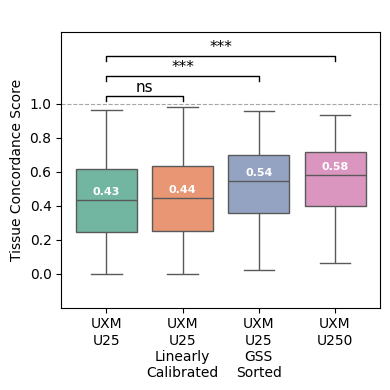

In [111]:
compare_methods_plot(uxm_tsc, uxm_tsc.columns[4:], show_points=False, baseline='UXM U25', figsize=(4,4), kind="box", bracket_step=0.12, test="mannwhitney", show_ns=True, title=" ", ylabel = "Tissue Concordance Score")

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


def compare_methods_plot(
    df,
    methods,
    baseline,
    test='wilcoxon',
    kind='violin',
    figsize=(8, 6),
    title=None,
    ylabel='Score',
    palette='Set2',
    show_points=True,
    show_ns=False,
    correction=None,
    y_max_value=1.0,
    y_min_value=0.0,
    bracket_step=0.07,
    label_sep = " ",
    ax=None,
):
    """
    Side-by-side violin or box plots of method scores, sorted by mean ascending,
    with significance brackets connecting the baseline to each other method.

    Parameters
    ----------
    baseline : str
        The method against which all others are tested and bracketed.
    kind : {'violin', 'box'}
        Plot type.
    show_ns : bool
        If True, draw brackets for non-significant comparisons too.
    correction : {None, 'bonferroni', 'fdr_bh'}
        Multiple testing correction across the baseline comparisons.
    y_max_value : float or None
        Hard upper bound on the y-axis (e.g. 1.0 for proportions). A dashed
        reference line is drawn at this value, and y-ticks above it are
        removed. Set to None to disable.
    """
    if baseline not in methods:
        raise ValueError(f"baseline '{baseline}' must be in methods")

    means = df[methods].mean().sort_values()
    order = means.index.tolist()
    long_df = df[methods].melt(var_name='method', value_name='value').dropna()

    test_funcs = {
        'wilcoxon':    lambda a, b: stats.wilcoxon(a, b),
        'ttest_rel':   lambda a, b: stats.ttest_rel(a, b),
        'ttest_ind':   lambda a, b: stats.ttest_ind(a, b, equal_var=False),
        'mannwhitney': lambda a, b: stats.mannwhitneyu(a, b, alternative='two-sided'),
    }
    if test not in test_funcs:
        raise ValueError(f"test must be one of {list(test_funcs)}")
    paired = test in ('wilcoxon', 'ttest_rel')

    def _annot(p):
        if np.isnan(p):  return 'n/a'
        if p <= 1e-3:    return '***'
        if p <= 1e-2:    return '**'
        if p <= 5e-2:    return '*'
        return 'ns'

    raw_results = []
    for m in order:
        if m == baseline:
            raw_results.append({'method': m, 'p_value': np.nan})
            continue
        if paired:
            pair = df[[baseline, m]].dropna()
            a, b = pair[baseline].values, pair[m].values
        else:
            a = df[baseline].dropna().values
            b = df[m].dropna().values
        try:
            p = float(test_funcs[test](a, b).pvalue)
        except ValueError:
            p = np.nan
        raw_results.append({'method': m, 'p_value': p})

    stats_df = pd.DataFrame(raw_results)

    if correction is not None:
        pvals = stats_df['p_value'].values
        valid = ~np.isnan(pvals)
        adj = np.full_like(pvals, np.nan, dtype=float)
        if correction == 'bonferroni':
            adj[valid] = np.minimum(pvals[valid] * valid.sum(), 1.0)
        elif correction == 'fdr_bh':
            v = pvals[valid]
            n = len(v)
            order_idx = np.argsort(v)
            ranked = v[order_idx]
            adj_ranked = ranked * n / (np.arange(n) + 1)
            adj_ranked = np.minimum.accumulate(adj_ranked[::-1])[::-1]
            adj_ranked = np.minimum(adj_ranked, 1.0)
            tmp = np.empty(n)
            tmp[order_idx] = adj_ranked
            adj[valid] = tmp
        else:
            raise ValueError("correction must be None, 'bonferroni', or 'fdr_bh'")
        stats_df['p_value_adj'] = adj
        stats_df['annotation'] = stats_df['p_value_adj'].apply(_annot)
    else:
        stats_df['annotation'] = stats_df['p_value'].apply(_annot)
    stats_df.loc[stats_df['method'] == baseline, 'annotation'] = ''

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if kind == 'violin':
        sns.violinplot(data=long_df, x='method', y='value', order=order,
                       palette=palette, inner='quartile', cut=0, ax=ax)
    elif kind == 'box':
        sns.boxplot(data=long_df, x='method', y='value', order=order,
                    palette=palette, ax=ax, fliersize=0)
    else:
        raise ValueError("kind must be 'violin' or 'box'")

    if show_points:
        sns.stripplot(data=long_df, x='method', y='value', order=order,
                      color='black', size=2.5, alpha=0.4, jitter=0.2, ax=ax)

    # for tick in ax.get_xticklabels():
    #     if tick.get_text() == baseline:
    #         tick.set_fontweight('bold')

    # --- significance brackets, baseline ↔ each other method ---
    y_max = long_df['value'].max()
    y_min = long_df['value'].min()
    span = (y_max - y_min) if y_max > y_min else 1.0

    # --- median labels next to each distribution's median line ---
    medians = df[methods].median()
    vertical_offset = 0.02 * span
    label_color = 'white' if kind == 'box' else 'black'
    label_weight = 'semibold' if kind == 'box' else 'normal'
    for i, m in enumerate(order):
        ax.text(i, medians[m] + vertical_offset, f'{medians[m]:.2f}',
                ha='center', va='bottom', fontsize=8,
                color=label_color, weight=label_weight)

    step = bracket_step * span
    base_y = y_max + 0.04 * span

    baseline_idx = order.index(baseline)
    pairs_to_draw = []
    for _, row in stats_df.iterrows():
        m = row['method']
        if m == baseline:
            continue
        ann = row['annotation']
        if ann == 'ns' and not show_ns:
            continue
        if ann == 'n/a':
            continue
        other_idx = order.index(m)
        xl, xr = min(baseline_idx, other_idx), max(baseline_idx, other_idx)
        pairs_to_draw.append((xl, xr, ann))

    pairs_to_draw.sort(key=lambda t: (t[1] - t[0], t[0]))

    bracket_h = step * 0.25
    for lvl, (xl, xr, ann) in enumerate(pairs_to_draw):
        y = base_y + lvl * step
        ax.plot([xl, xl, xr, xr],
                [y, y + bracket_h, y + bracket_h, y],
                lw=1.0, c='black')
        ax.text((xl + xr) / 2, y + bracket_h + step * 0.04,
                ann, ha='center', va='bottom', fontsize=11)

    # --- axis ceiling ---
    top_y = base_y + max(len(pairs_to_draw) - 1, 0) * step + step
    upper_lim = top_y + 0.05 * span

    if y_max_value is not None:
        ax.axhline(y_max_value, ls='--', lw=0.8, color='grey', alpha=0.7, zorder=0)
        upper_lim = max(upper_lim, y_max_value + 0.02 * span)

    ax.set_ylim(y_min - 0.05 * span, upper_lim)
    if y_min_value is not None:
        cur_lo, cur_hi = ax.get_ylim()
        ax.set_ylim(max(cur_lo, y_min_value - 0.02 * span), cur_hi)

    if y_max_value is not None:
        ticks = [t for t in ax.get_yticks() if t <= y_max_value + 1e-9]
        if ticks and ticks[-1] < y_max_value - 1e-9:
            ticks = ticks + [y_max_value]
        ax.set_yticks(ticks)

    if y_min_value is not None:
        ticks = [t for t in ax.get_yticks() if t >= y_min_value - 1e-9]
        if ticks and ticks[0] > y_min_value + 1e-9:
            ticks = [y_min_value] + ticks
        ax.set_yticks(ticks)

    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title or f'Compared to baseline: {baseline} ({test})')
    new_labels = [lbl.get_text().replace(label_sep, '\n')
                  for lbl in ax.get_xticklabels()]
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(new_labels, rotation=0, ha='center')
    # ax.tick_params(axis='x', rotation=20)
    # for lbl in ax.get_xticklabels():
    #     lbl.set_ha('right')

    plt.tight_layout()
    return ax, stats_df

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


def violin_compare_methods(
    df,
    methods,
    baseline,
    test='wilcoxon',
    figsize=(8, 6),
    title=None,
    ylabel='Tissue Concordance Score',
    palette='Set2',
    show_points=True,
    ax=None,
):
    """
    Side-by-side violin plots of method scores, sorted by mean ascending,
    with pairwise significance annotations comparing each non-baseline
    method to the baseline.

    Parameters
    ----------
    df : pd.DataFrame
        Wide-format dataframe where each method is a column of numeric scores.
    methods : list of str
        Column names to compare. Must include `baseline`.
    baseline : str
        The method against which all others are tested.
    test : {'wilcoxon', 'ttest_rel', 'ttest_ind', 'mannwhitney'}
        Statistical test for pairwise comparisons.
        - 'wilcoxon' / 'ttest_rel': paired (rows are matched samples).
        - 'mannwhitney' / 'ttest_ind': independent.
    figsize : tuple
        Figure size (ignored if `ax` is provided).
    title, ylabel : str
        Plot labels.
    palette : str or list
        Seaborn palette.
    show_points : bool
        Overlay individual observations as a stripplot.
    ax : matplotlib.axes.Axes or None
        Existing axis to draw onto. If None, a new figure/axis is created.

    Returns
    -------
    ax : matplotlib.axes.Axes
    stats_df : pd.DataFrame
        Pairwise test results (method, mean, p_value, annotation).
    """
    if baseline not in methods:
        raise ValueError(f"baseline '{baseline}' must be in methods")

    # --- prepare long-form data, sorted by mean ascending ---
    means = df[methods].mean().sort_values()
    order = means.index.tolist()

    long_df = df[methods].melt(var_name='method', value_name='value').dropna()

    # --- pairwise tests vs baseline ---
    test_funcs = {
        'wilcoxon':    lambda a, b: stats.wilcoxon(a, b),
        'ttest_rel':   lambda a, b: stats.ttest_rel(a, b),
        'ttest_ind':   lambda a, b: stats.ttest_ind(a, b, equal_var=False),
        'mannwhitney': lambda a, b: stats.mannwhitneyu(a, b, alternative='two-sided'),
    }
    if test not in test_funcs:
        raise ValueError(f"test must be one of {list(test_funcs)}")
    paired = test in ('wilcoxon', 'ttest_rel')

    def _annot(p):
        if np.isnan(p):     return 'n/a'
        if p < 1e-4:        return '****'
        if p < 1e-3:        return '***'
        if p < 1e-2:        return '**'
        if p < 5e-2:        return '*'
        return 'ns'

    results = []
    for m in order:
        if m == baseline:
            results.append({'method': m, 'mean': means[m],
                            'p_value': np.nan, 'annotation': 'baseline'})
            continue

        if paired:
            pair = df[[baseline, m]].dropna()
            a, b = pair[baseline].values, pair[m].values
        else:
            a = df[baseline].dropna().values
            b = df[m].dropna().values

        try:
            p = float(test_funcs[test](a, b).pvalue)
        except ValueError:
            # e.g. wilcoxon with all-zero differences
            p = np.nan

        results.append({'method': m, 'mean': means[m],
                        'p_value': p, 'annotation': _annot(p)})

    stats_df = pd.DataFrame(results)

    # --- plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.violinplot(
        data=long_df, x='method', y='value', order=order,
        palette=palette, inner='quartile', cut=0, ax=ax,
    )
    if show_points:
        sns.stripplot(
            data=long_df, x='method', y='value', order=order,
            color='black', size=2.5, alpha=0.4, jitter=0.2, ax=ax,
        )

    # highlight the baseline tick label
    for tick in ax.get_xticklabels():
        if tick.get_text() == baseline:
            tick.set_fontweight('bold')

    # --- annotate p-values above each violin ---
    y_max = long_df['value'].max()
    y_min = long_df['value'].min()
    span = y_max - y_min if y_max > y_min else 1.0
    annot_y = y_max + 0.06 * span

    for i, m in enumerate(order):
        row = stats_df.loc[stats_df['method'] == m].iloc[0]
        if m == baseline:
            label = f'{baseline}\n(baseline)'
        else:
            p = row['p_value']
            ptxt = 'p=n/a' if np.isnan(p) else (
                f'p={p:.1e}' if p < 1e-3 else f'p={p:.3f}'
            )
            label = f"{row['annotation']}\n{ptxt}"
        ax.text(i, annot_y, label, ha='center', va='bottom', fontsize=9)

    ax.set_ylim(y_min - 0.05 * span, annot_y + 0.12 * span)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title or f'Methods compared to baseline: {baseline} ({test})')
    new_labels = [lbl.get_text().replace('_', '\n') for lbl in ax.get_xticklabels()]
    ax.set_xticklabels(new_labels, rotation=0, ha='center')
    ax.tick_params(axis='x', rotation=20)
    for lbl in ax.get_xticklabels():
        lbl.set_ha('right')

    plt.tight_layout()
    return ax, stats_df